### Call a subgraph inside a Node

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [13]:
from typing import Annotated, TypedDict, List
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

In [52]:
load_dotenv()

True

In [53]:
parent_llm = ChatGroq(
    model = "llama-3.1-8b-instant"
    )

subgraph_llm = ChatGroq(
    model = "llama-3.1-8b-instant"
)

In [54]:
class SubState(TypedDict):
    input_text: str
    translated_text: str

In [72]:
def translate_text(state: SubState):

    prompt = f"""
                Translate the following text to Bengali.
                Keep it natural and clear. Do not add extra content. You must answer with in 10 words.

                Text:
                {state["input_text"]}
            """.strip()
    
    translated_text = subgraph_llm.invoke(prompt).content

    return {'translated_text': translated_text}

In [73]:
subgraph_builder = StateGraph(SubState)

subgraph_builder.add_node('translate_text', translate_text)

subgraph_builder.add_edge(START, 'translate_text')
subgraph_builder.add_edge('translate_text', END)

subgraph = subgraph_builder.compile()

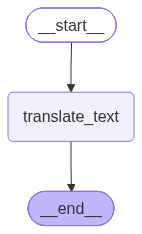

In [74]:
subgraph

In [75]:
## main graph 


class ParentState(TypedDict):
    question : str
    answer_eng : str
    answer_hin : str


In [76]:
def generate_answer(state: ParentState):

    answer = parent_llm.invoke(
        f"You are a helpful assistant. Answer clearly.\n\nQuestion: {state['question']}"
        ).content
    return {'answer_eng': answer}

In [77]:
def translate_answer(state : ParentState):
    ## call the subgraph 
    result = subgraph.invoke(
        {
            'input_text' : state['answer_eng']
        }
    )
    return {
        'answer_hin' : result['translated_text']
    }

In [78]:
parent_builder = StateGraph(ParentState)

parent_builder.add_node("answer", generate_answer)
parent_builder.add_node("translate", translate_answer)

parent_builder.add_edge(START, 'answer')
parent_builder.add_edge('answer', 'translate')
parent_builder.add_edge('translate', END)

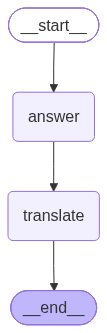

In [79]:
graph = parent_builder.compile()

graph

In [80]:
res = graph.invoke({'question': 'What is quantum physics'})
res['answer_hin']

'কোয়ান্টাম পদার্থবিজ্ঞান হলো একটি পদার্থবিজ্ঞানের শাখা যা পদার্থ এবং শক্তির আণবিক ও সূক্ষ্ম স্তরের আচরণ নিয়ে কাজ করে।'